In [2]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

import sys 
import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint
from datasets import LetterStringDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# import lewis mitchell problems to dataloader:
D_lewis_mitchell = LetterStringDataset("test", "../data/lewis_mitchell", batch_size=2000)
test_lm = DataLoader(D_lewis_mitchell, batch_sampler=D_lewis_mitchell.sampler, collate_fn=D_lewis_mitchell.collate_fn)

# load checkpoint and best model:
cp_perm_200 = CheckPoint.from_pt("../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")
model_perm_200 = cp_perm_200.load_model(verbose=False)

In [99]:
lm_alphs = pd.read_csv("../data/lewis_mitchell/test.csv")
trained_alphs = pd.read_csv(f"../{cp_perm_200.train_config.dir_data}/train.csv")
set(lm_alphs.alphabet.unique()) & set(trained_alphs.alphabet.unique())

{'a b c d e f g h i j k l m n o p q r s t u v w x y z'}

In [81]:
pred_perm_200 = analysis_utils.predict_dataset(test_lm, model_perm_200, alternative_rule_errors=False)

Predicting: 2it [00:04,  2.25s/it]                       


In [82]:
pred_perm_200.rename(columns={"n_perm": "nperms", "transformation": "prob_type"}, inplace=True)
pred_perm_200["total"] = 1
pred_perm_200["promptstyle"] = "MLC"
pred_perm_200["model"] = "MLC"

pred_perm_200 = pred_perm_200[["model", "promptstyle", "nperms", "prob_type", "correct", "total"]]
pred_perm_200.loc[pred_perm_200["nperms"]==1,"nperms"] = 0
pred_perm_200["nperms"] = pred_perm_200["nperms"].apply(lambda x: "np_" + str(x))

In [83]:
pred_perm_200

,model,promptstyle,nperms,prob_type,correct,total
0,MLC,MLC,np_5,add_letter,True,1
1,MLC,MLC,np_10,add_letter,True,1
2,MLC,MLC,np_5,succ,True,1
3,MLC,MLC,np_5,fix_alphabet,True,1
4,MLC,MLC,np_20,succ,True,1
...,...,...,...,...,...,...
2074,MLC,MLC,np_0,remove_redundant,True,1
2075,MLC,MLC,np_20,remove_redundant,True,1
2076,MLC,MLC,np_2,pred,True,1
2077,MLC,MLC,np_2,sort,True,1


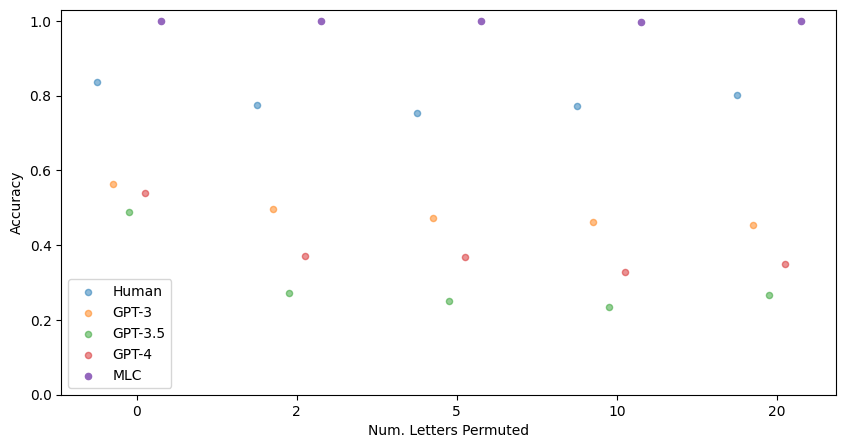

In [ ]:
# reproduce human/GPT comparison plot without error bars and with MLC predictions included, excluding symbol alphabets:
full_df = pd.read_csv("https://raw.githubusercontent.com/marthaflinderslewis/counterfactual_analogy/refs/heads/main/data/data.csv")
full_df = pd.concat([full_df, pred_perm_200])
models = ['human', '3', '35', '4', "MLC"]
nperms = [f'np_{i}' for i in [1, 2, 5, 10, 20]]
promptstyles = ['human', 'human-like', 'webb', 'minimal', 'hw', 'MLC']

# Group df by model, nperms and promptstyle
grouped_df = full_df[full_df.prob_type!='attn']
grouped_df = full_df[full_df.nperms!='np_symb']
grouped_df = grouped_df.groupby(['model', 'promptstyle', 'nperms'], as_index=False).sum()
grouped_df = grouped_df.drop(columns='prob_ind')

grouped_df['acc'] = grouped_df['correct']/grouped_df['total']
grouped_df['model'] = pd.Categorical(grouped_df['model'], ordered = True, categories = models)
grouped_df['promptstyle'] = pd.Categorical(grouped_df['promptstyle'], ordered = True, categories = promptstyles)
grouped_df['nperms'] = pd.Categorical(grouped_df['nperms'], ordered = True, categories = nperms)
grouped_df = grouped_df.sort_values(['model', 'promptstyle', 'nperms'])


fig, ax = plt.subplots(figsize=(10,5))
ax.set_ylabel("Accuracy")

# Get data that is either human or uses Hodel and West prompt
df_slice = grouped_df[(grouped_df.promptstyle=='human')|(grouped_df.promptstyle=='hw')|(grouped_df.promptstyle=='MLC')]


for j, model in enumerate(models):
    # get the accuracies
    accs = df_slice[df_slice.model == model]['acc']

    scat = ax.scatter(np.arange(len(accs)) + j*0.1, accs, s=20, alpha=1 if model=="MLC" else 0.5)

    # put the legend on the last plot
    ax.legend(['Human', 'GPT-3', 'GPT-3.5', 'GPT-4', 'MLC']) 
    # put the xtick labels, offset by 0.2 to put them in the centre of each group of points
    ax.set_xticks(np.arange(len(nperms))+0.25)
    ax.set_xticklabels([0, 2, 5, 10, 20])
    ax.set_xlabel('Num. Letters Permuted')
    ax.set_ylim([0, 1.03])